In [1]:
import os
import cv2
import numpy as np
import mediapipe as mp
from sklearn.metrics.pairwise import cosine_similarity
from collections import deque

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

STD_VIDEO = "videos/queen4.mp4"
USR_VIDEO = "videos/queen2.mp4"

SMOOTH_WIN = 10
LOW_SCORE_TH = 0.90
SAVE_LOW_MAX = 50
MAX_WIDTH = 1200

OUT_DIR = "manual_align_results"
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
JOINT_WEIGHTS = np.ones(33)
JOINT_WEIGHTS[[11,12,13,14,15,16]] = 2.0  # 手臂更重要

def extract_pose_feature(pose, frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    res = pose.process(rgb)
    if not res.pose_landmarks:
        return None, res

    feat = np.zeros(66, dtype=np.float32)
    for i, lm in enumerate(res.pose_landmarks.landmark):
        feat[i*2]   = lm.x
        feat[i*2+1] = lm.y
    return feat, res

def normalize_pose(feat66):
    feat = feat66.reshape(-1, 2).copy()
    hip = mp_pose.PoseLandmark.LEFT_HIP.value
    sh  = mp_pose.PoseLandmark.LEFT_SHOULDER.value

    center = feat[hip]
    feat -= center
    norm = np.linalg.norm(feat[sh] - feat[hip])
    if norm > 1e-6:
        feat /= norm
    return feat.flatten()

def weighted_cosine(f1, f2):
    w = np.repeat(JOINT_WEIGHTS, 2)
    return cosine_similarity([f1*w], [f2*w])[0][0]


In [3]:
# =========================================
# Cell 3: Manual alignment for BOTH videos
#       (UI-visible version)
# =========================================

cap_std = cv2.VideoCapture(STD_VIDEO)
cap_usr = cv2.VideoCapture(USR_VIDEO)

if not cap_std.isOpened() or not cap_usr.isOpened():
    raise RuntimeError("视频无法打开，请检查路径")

total_std_frames = int(cap_std.get(cv2.CAP_PROP_FRAME_COUNT))
total_usr_frames = int(cap_usr.get(cv2.CAP_PROP_FRAME_COUNT))

cv2.namedWindow("Manual Alignment", cv2.WINDOW_NORMAL)

COARSE_STEP = 10
std_offset = 0
usr_offset = 0

active_video = "std"   # 当前控制对象
input_mode = False
input_buffer = ""

def on_std_trackbar(val):
    global std_offset
    std_offset = min(val * COARSE_STEP, total_std_frames - 1)

def on_usr_trackbar(val):
    global usr_offset
    usr_offset = min(val * COARSE_STEP, total_usr_frames - 1)

cv2.createTrackbar(
    "STD Start (x10)", "Manual Alignment",
    0, (total_std_frames - 1)//COARSE_STEP, on_std_trackbar
)
cv2.createTrackbar(
    "USR Start (x10)", "Manual Alignment",
    0, (total_usr_frames - 1)//COARSE_STEP, on_usr_trackbar
)

print("========= 双视频手动对齐 =========")
print("TAB 切换视频 | I 输入帧号 | ←/→ ±1 帧")
print("Enter 确认 | Esc 退出")
print("================================")

def draw_panel(img, lines, y0=10):
    """左上角半透明 UI 面板"""
    overlay = img.copy()
    h = 30 + 30 * len(lines)
    cv2.rectangle(overlay, (5, y0), (520, y0+h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.5, img, 0.5, 0, img)

    y = y0 + 30
    for line in lines:
        cv2.putText(
            img, line, (15, y),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8,
            (0, 255, 255), 2
        )
        y += 30

while True:
    cap_std.set(cv2.CAP_PROP_POS_FRAMES, std_offset)
    cap_usr.set(cv2.CAP_PROP_POS_FRAMES, usr_offset)

    r1, f1 = cap_std.read()
    r2, f2 = cap_usr.read()
    if not (r1 and r2):
        break

    # 等比缩放到同一高度
    target_h = min(f1.shape[0], f2.shape[0])
    def resize_h(img):
        h, w = img.shape[:2]
        if h == target_h:
            return img
        return cv2.resize(img, (int(w*target_h/h), target_h))

    f1r = resize_h(f1)
    f2r = resize_h(f2)
    combined = np.hstack((f1r, f2r))

    # 显示用 resize
    disp = combined
    if disp.shape[1] > MAX_WIDTH:
        s = MAX_WIDTH / disp.shape[1]
        disp = cv2.resize(
            disp,
            (int(disp.shape[1]*s), int(disp.shape[0]*s))
        )

    # -------- UI 提示（始终画在最终显示帧上）--------
    lines = [
        f"STD offset: {std_offset}" + ("  <==" if active_video=="std" else ""),
        f"USR offset: {usr_offset}" + ("  <==" if active_video=="usr" else ""),
        "TAB: switch  I: input ",
        "<-/->: +/-1",
        "Enter: confirm  Esc: exit"
    ]
    if input_mode:
        lines.append(f"Input: {input_buffer}")

    draw_panel(disp, lines)

    cv2.imshow("Manual Alignment", disp)

    key = cv2.waitKey(30) & 0xFF

    # ---------- 输入模式优先 ----------
    if input_mode:
        if key == 13:  # Enter
            if input_buffer.isdigit():
                val = int(input_buffer)
                if active_video == "std":
                    std_offset = min(val, total_std_frames - 1)
                else:
                    usr_offset = min(val, total_usr_frames - 1)
            input_mode = False
            input_buffer = ""
        elif key == 27:
            input_mode = False
            input_buffer = ""
        elif key == 8:
            input_buffer = input_buffer[:-1]
        elif 48 <= key <= 57:
            input_buffer += chr(key)
        continue

    # ---------- 普通模式 ----------
    if key == 27:
        std_offset = None
        usr_offset = None
        break
    elif key == 13:
        break
    elif key == 9:
        active_video = "usr" if active_video == "std" else "std"
    elif key == ord('i'):
        input_mode = True
        input_buffer = ""
    elif key == 81:  # ←
        if active_video == "std":
            std_offset = max(0, std_offset - 1)
        else:
            usr_offset = max(0, usr_offset - 1)
    elif key == 83:  # →
        if active_video == "std":
            std_offset = min(total_std_frames - 1, std_offset + 1)
        else:
            usr_offset = min(total_usr_frames - 1, usr_offset + 1)

cv2.destroyWindow("Manual Alignment")
cap_std.release()
cap_usr.release()

if std_offset is None or usr_offset is None:
    raise RuntimeError("未选择起始帧")

print("✅ Selected STD start frame:", std_offset)
print("✅ Selected USR start frame:", usr_offset)


========= 双视频手动对齐 =========
TAB 切换视频 | I 输入帧号 | ←/→ ±1 帧
Enter 确认 | Esc 退出
✅ Selected STD start frame: 0
✅ Selected USR start frame: 0


In [4]:
# =========================================
# Cell 4: Scoring loop (no distortion, record all frames)
# =========================================

cap_std = cv2.VideoCapture(STD_VIDEO)
cap_usr = cv2.VideoCapture(USR_VIDEO)

cap_std.set(cv2.CAP_PROP_POS_FRAMES, std_offset)
cap_usr.set(cv2.CAP_PROP_POS_FRAMES, usr_offset)

pose1 = mp_pose.Pose()
pose2 = mp_pose.Pose()

cv2.namedWindow("Action Comparison", cv2.WINDOW_NORMAL)

score_buf = deque(maxlen=SMOOTH_WIN)

all_scores = []   # 每帧平滑分
all_frames = []   # 保存“原始分辨率的拼接帧”（用于后处理导出视频）

def resize_to_height_keep_aspect(img, target_h):
    """等比缩放到指定高度，不改变纵横比"""
    h, w = img.shape[:2]
    if h == target_h:
        return img
    scale = target_h / h
    new_w = max(1, int(w * scale))
    return cv2.resize(img, (new_w, target_h), interpolation=cv2.INTER_AREA)

frame_idx = 0

while True:
    r1, frame1 = cap_std.read()
    r2, frame2 = cap_usr.read()
    if not (r1 and r2):
        break

    # ========= Pose + skeleton =========
    feat1, res1 = extract_pose_feature(pose1, frame1)
    feat2, res2 = extract_pose_feature(pose2, frame2)

    if res1.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame1, res1.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            mp_drawing_styles.get_default_pose_landmarks_style()
        )
    if res2.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame2, res2.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            mp_drawing_styles.get_default_pose_landmarks_style()
        )

    # ========= 评分 =========
    score_smooth = None
    if feat1 is not None and feat2 is not None:
        raw_score = weighted_cosine(normalize_pose(feat1), normalize_pose(feat2))
        score_buf.append(raw_score)
        score_smooth = float(np.mean(score_buf))
        all_scores.append(score_smooth)

    # ========= 等比缩放到同一高度（不拉伸） =========
    target_h = min(frame1.shape[0], frame2.shape[0])  # 也可以换成固定高度，比如 480
    f1r = resize_to_height_keep_aspect(frame1, target_h)
    f2r = resize_to_height_keep_aspect(frame2, target_h)

    combined_raw = np.hstack((f1r, f2r))

    # ========= 叠字（叠在 raw 上，保存/导出用） =========
    if score_smooth is not None:
        cv2.putText(
            combined_raw,
            f"Score: {score_smooth*100:.1f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2
        )
        # 只在有分数时记录
        all_frames.append(combined_raw.copy())

    # ========= 显示用（仅缩放整张拼接图，不改变比例） =========
    combined_disp = combined_raw
    h, w = combined_disp.shape[:2]
    if w > MAX_WIDTH:
        scale = MAX_WIDTH / w
        combined_disp = cv2.resize(
            combined_disp,
            (int(w * scale), int(h * scale)),
            interpolation=cv2.INTER_AREA
        )

    cv2.imshow("Action Comparison", combined_disp)

    if cv2.waitKey(1) & 0xFF in [27, ord('q')]:
        break

    frame_idx += 1

cap_std.release()
cap_usr.release()
pose1.close()
pose2.close()
cv2.destroyAllWindows()

print(f"Scored frames: {len(all_scores)}")


D:\AllCode\ImageProcess\aidance\.venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
D:\AllCode\ImageProcess\aidance\.venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
D:\AllCode\ImageProcess\aidance\.venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
D:\AllCode

Scored frames: 479


In [5]:
# =========================================
# Cell 5: Final score + lowest 5% + TNMS
# =========================================

import numpy as np

scores = np.array(all_scores, dtype=np.float32)

if len(scores) == 0:
    raise RuntimeError("没有有效评分帧，无法计算结果")

# ========= 总评分 =========
mean_score = scores.mean() * 100
trim_score = np.sort(scores)[int(0.1 * len(scores)):].mean() * 100

print(f"Total Score (mean):   {mean_score:.2f}")
print(f"Total Score (trim10): {trim_score:.2f}")

# ========= Step 1: 取最低 5% =========
N = len(scores)
k = max(1, int(0.05 * N))   # 至少取 1 帧

lowest_idx = np.argsort(scores)[:k]   # 从低到高

print(f"Initial lowest frames: {k} / {N} (5%)")

# ========= Step 2: 时间去邻近（只保留局部低谷） =========
# 在这个窗口内，只保留分数最低的一帧
MIN_GAP = 5   # 帧间隔阈值（可调，5~10 都合理）

selected_idx = []

for idx in lowest_idx:
    keep = True
    for j in selected_idx:
        if abs(idx - j) <= MIN_GAP:
            # 如果时间上太近，只保留分数更低的
            if scores[idx] < scores[j]:
                selected_idx.remove(j)
            else:
                keep = False
            break
    if keep:
        selected_idx.append(idx)

# 按时间顺序排序（方便查看）
selected_idx = sorted(selected_idx)

print(f"After temporal suppression: {len(selected_idx)} frames kept")

# ========= 保存关键低谷帧 =========
for rank, idx in enumerate(selected_idx):
    s = scores[idx]
    img = all_frames[idx]
    cv2.imwrite(
        f"{OUT_DIR}/low_key{rank+1:02d}_frame{idx}_score{s:.3f}.jpg",
        img
    )

# ========= 保存 CSV =========
with open(f"{OUT_DIR}/scores.csv", "w") as f:
    f.write("frame,score\n")
    for i, s in enumerate(scores):
        f.write(f"{i},{s}\n")

print("✅ Key low-score frames (after TNMS) saved to:", OUT_DIR)


Total Score (mean):   94.68
Total Score (trim10): 96.04
Initial lowest frames: 23 / 479 (5%)
After temporal suppression: 4 frames kept
✅ Key low-score frames (after TNMS) saved to: manual_align_results


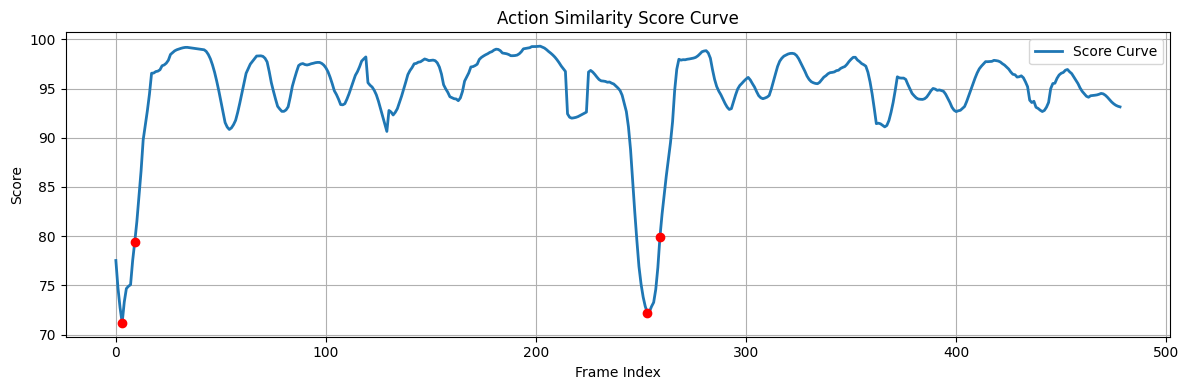

In [6]:
# =========================================
# Cell 6: Score curve visualization
# =========================================

import matplotlib.pyplot as plt
import numpy as np

scores_np = np.array(all_scores)

plt.figure(figsize=(12, 4))
plt.plot(scores_np * 100, label="Score Curve", linewidth=2)

# 标注关键低谷帧
for idx in selected_idx:
    plt.scatter(idx, scores_np[idx] * 100, c='red', zorder=5)

plt.xlabel("Frame Index")
plt.ylabel("Score")
plt.title("Action Similarity Score Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


In [7]:
# ==========================================================
# Cell: Save score curve + multiple low-score MP4 clips
# ==========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

os.makedirs(OUT_DIR, exist_ok=True)

scores_np = np.array(all_scores, dtype=np.float32)
T = len(all_frames)

# ----------------------------------------------------------
# Part 1: 保存分数曲线图（PNG）
# ----------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(scores_np * 100, linewidth=2, label="Score Curve")

for idx in selected_idx:
    plt.scatter(idx, scores_np[idx] * 100, c='red', zorder=5)

plt.xlabel("Frame Index")
plt.ylabel("Score")
plt.title("Action Similarity Score Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()

curve_path = os.path.join(OUT_DIR, "score_curve.png")
plt.savefig(curve_path, dpi=150)
plt.close()

print("✅ Saved score curve:", curve_path)

# ----------------------------------------------------------
# Part 2: 生成并合并低分区间
# ----------------------------------------------------------
CLIP_RADIUS = 20   # 每个低谷前后 ±20 帧
FPS = 15

def merge_intervals(intervals):
    """
    合并重叠或相邻的时间区间
    """
    if not intervals:
        return []

    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]

    for s, e in intervals[1:]:
        ls, le = merged[-1]
        if s <= le + 1:
            merged[-1] = (ls, max(le, e))
        else:
            merged.append((s, e))
    return merged

# 原始区间
raw_intervals = []
for idx in selected_idx:
    start = max(0, idx - CLIP_RADIUS)
    end   = min(T - 1, idx + CLIP_RADIUS)
    raw_intervals.append((start, end))

# 合并后的区间
merged_intervals = merge_intervals(raw_intervals)

print("Low-score intervals:")
for i, (s, e) in enumerate(merged_intervals):
    print(f"  Clip {i+1}: frames [{s}, {e}]")

# ----------------------------------------------------------
# Part 3: 每个区间单独生成一个 MP4
# ----------------------------------------------------------
H, W, _ = all_frames[0].shape
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

for clip_id, (start, end) in enumerate(merged_intervals, start=1):
    out_path = os.path.join(OUT_DIR, f"low_score_clip_{clip_id:02d}.mp4")
    writer = cv2.VideoWriter(out_path, fourcc, FPS, (W, H))

    for idx in range(start, end + 1):
        frame = all_frames[idx].copy()

        # 标注当前帧分数
        cv2.putText(
            frame,
            f"Score: {scores_np[idx]*100:.1f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            2
        )

        writer.write(frame)

    writer.release()
    print(f"✅ Saved MP4 clip {clip_id}: {out_path}")


✅ Saved score curve: manual_align_results\score_curve.png
Low-score intervals:
  Clip 1: frames [0, 29]
  Clip 2: frames [233, 279]
✅ Saved MP4 clip 1: manual_align_results\low_score_clip_01.mp4
✅ Saved MP4 clip 2: manual_align_results\low_score_clip_02.mp4
